# Sandwich week 2025 singlet oxygen experiment template:

# Things to note before using this template
- You will need to upload UV-Vis absorbance data and manually input HPLC integration data 
- Make sure you upload the csv data files from UV-Vis, they should work in the format that the UV-Vis software provides them, otherwise convert it to UTF-8 encoded csv files (but only if you need to, its easier to just upload the files directly from UV-Vis)
- Everywhere there is _____ , change a name to match the name of your file
- When you are extracting the absorbance data from the UV-Vis, change the "unnamed" variables to match the measurements you took 

- Any questions/comments/suggestions can be sent to Keighan (keighan@chem.ubc.ca) 
- Last updated on June 20, 2025

# Import Packages

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from scipy.optimize import minimize
from matplotlib.colors import LogNorm

# Read in Irradiance data (previously measured)

In [ ]:
# Read the irradiance data from the CSV file
dfIrr2 = pd.read_csv('UVA+UVB_Irr.csv', skiprows=[1])
dfIrr2.columns = ['AbsoluteIrradiance:245', 'Unnamed: 1']

# Round the wavelengths to the nearest whole number
dfIrr2['rounded_wavelength'] = dfIrr2['AbsoluteIrradiance:245'].round()

dfIrr2.loc[dfIrr2['rounded_wavelength'] < 300, 'Unnamed: 1'] = 0

# Filter the DataFrame to include only wavelengths from 200 to 800
filtered_df1 = dfIrr2[(dfIrr2['rounded_wavelength'] >= 200) & (dfIrr2['rounded_wavelength'] <= 800)]

# Group by the rounded wavelengths and calculate the average irradiance
average_irradiance2 = filtered_df1.groupby('rounded_wavelength')['Unnamed: 1'].mean().reset_index()

# Rename the columns for clarity
average_irradiance2.columns = ['wavelength', 'average_irradiance']

Irr2=average_irradiance2['average_irradiance']
wavelengthIrr=average_irradiance2['wavelength']

Irr2=Irr2.astype(float)
wavelengthIrr=wavelengthIrr.astype(float)
I_rel=Irr2/np.sum(Irr2)

# Chemical Actinometry using 2-nitrobenzaldehyde

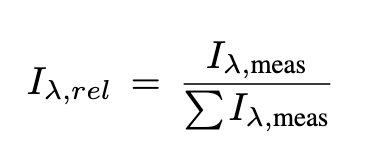

In [ ]:
# Load data
df = pd.read_csv('E2NB.csv')
wavelength_2NB = df['λ (nm)']
E2NB = df['2NB E'][:501]
wavelength_2NB = wavelength_2NB[:501]

I_rel_sub = I_rel[:501][::-1]  

fig, ax1 = plt.subplots(figsize=(8, 4), dpi=300)

# Left y-axis: Molar absorptivity
ax1.plot(wavelength_2NB, E2NB, 'g')
ax1.set_ylabel('2NB Molar Absorptivity (M$^{-1}$ cm$^{-1}$)', color='g')
ax1.tick_params(axis='y', labelcolor='g')
ax1.set_ylim(0,7000)

# Right y-axis: Irradiance
ax2 = ax1.twinx()
ax2.plot(wavelength_2NB, I_rel_sub, color='purple')
ax2.fill_between(wavelength_2NB, I_rel_sub, color='purple', alpha=0.5)
ax2.set_ylabel('Normalized Irradiance', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax2.set_ylim(0,0.025)

# Shared x-axis
ax1.set_xlabel('Wavelength (nm)')
ax1.set_xlim(200,800)

plt.tight_layout()
plt.show()


In [1]:
time=np.array([0,1,2,3,5])*60
deg=[]
deglog=np.log([i/deg[0] for i in deg])
kobs_2NB=-(np.polyfit(time,deglog,1)[0])
#Plot the results
plt.plot(time,deglog,'bo')
plt.plot(time,time*(-kobs_2NB),'b--')

#Plot legend and axis labels
#plt.legend(fontsize=14)
plt.ylabel('ln(${[2NB]_t}$/${[2NB]_0}$)',fontsize=12)
plt.xlabel('Irradiation time (sec)',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.savefig('2NB_decay')
plt.show()

NameError: name 'np' is not defined

# Calculate scaling factor based on measured decay of chemical actinometer
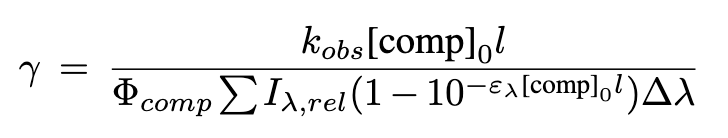


In [2]:
quantum2NB=0.41
def optimize_scaling_factor(quantum2NB, E2NB, I_rel_sub, known_value):
    """
    Optimize the scaling factor to match the known action_spectra value.

    Parameters:
        quantum2NB: Quantum yield.
        E2NB (pandas.Series or np.ndarray): Molar absorptivity data.
        I_rel_sub (pandas.Series or np.ndarray): Relative intensity data.
        known_value (float): The known action_spectra value to match.

    Returns:
        float: The optimal scaling factor.
    """
    # Reset index and ensure inputs are numpy arrays for better performance
    quantum2NB = quantum2NB
    E2NB = E2NB
    I_rel_sub = I_rel_sub.reset_index(drop=True).values

    # Objective function to minimize the error
    def objective(scaling_factor):
        action_spectra = 2.303 * scaling_factor * quantum2NB *  E2NB * I_rel_sub
        error = np.abs(np.sum(action_spectra) - known_value)  # Minimize absolute error
        return error

    # Initial guess for the scaling factor
    initial_guess = 0.01

    # Perform the optimization
    result = minimize(objective, initial_guess, method='Nelder-Mead',tol=1e-10)

    if result.success:
        optimal_scaling_factor = result.x[0]
        
        optimized_action_spectra = 2.303 * optimal_scaling_factor * quantum2NB *  E2NB * I_rel_sub
        optimized_value = np.sum(optimized_action_spectra)

        print(f"Known value: {known_value}")
        print(f"Optimized action_spectra value: {optimized_value}")

        return optimal_scaling_factor
    else:
        raise ValueError("Optimization failed: " + result.message)

scaling_factor = optimize_scaling_factor(quantum2NB, E2NB, I_rel_sub, kobs_2NB)
print(f"Optimized scaling factor: {scaling_factor}")

NameError: name 'E2NB' is not defined

# Calculate absolute irradiance using scaling factor
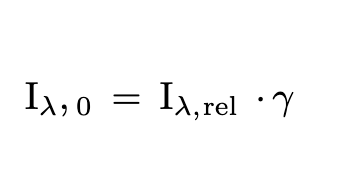

In [ ]:
I_abs_2NB=I_rel.reset_index(drop=True)*scaling_factor

c=3*10**8 #m/s
h=6.626*10**-34 #J s
Na=6.023*10**23 #mol^-1

print('Integrated Irradiance (200 to 800 nm) =',np.sum(I_abs_2NB.reset_index(drop=True)*h*c*Na*10**10/wavelengthIrr.reset_index(drop=True)),'W m^2')

# Read in the UV-Vis data as a CSV File

In [ ]:
#First you will need to upload your csv file to this server
#then read in csv file as pandas dataframe, skipping the 2nd row
df = pd.read_csv('___.csv', skiprows=[1]) #change the name of the csv file to the name of the file you imported

#this will output the table again from pandas (pd). make sure you are pulling out the correct data in the next block of code
df

In [ ]:
Jug_abs = df['Unnamed: x']
PN_abs = df['Unnamed: x']
wavelength=np.linspace(800,200,601)

#Do a baseline correction
Jug_abs=Jug_abs-np.mean(Jug_abs[0:100])
PN_abs=PN_abs-np.mean(PN_abs[0:100])

#change all absorbances to type 'float' for ease of calculations 
Jug_abs=Jug_abs.astype(float)
PN_abs=PN_abs.astype(float)
wavelength=wavelength.astype(float)

#Set negative absorbance values to be 0 
Jug_abs[Jug_abs < 0] = 0
PN_abs[PN_abs < 0] = 0

wavelength=wavelength[::-1]
Jug_abs=Jug_abs[::-1]
PN_abs=PN_abs[::-1]

In [ ]:
# Plot the absorbance as a function of wavelength for each sample
fig,ax1=plt.subplots(figsize=(8,5),dpi=200)

#add twin axis to plot absorbance and irradiance 
ax2=ax1.twinx()

ax1.plot(wavelength, Jug_abs,'g', label='Juglone')
ax1.plot(wavelength, PN_abs,'y', label='Perinaphthenone')

ax2.plot(wavelength,I_rel,color='purple',label='Irradiance')
plt.fill_between(wavelength,I_rel, 0, color='purple', alpha=.2)


# Add a legend and axis labels
ax1.legend()
ax2.legend(loc='center right')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Absorbance')
ax2.set_ylabel('Normalized Irradiance')
ax1.set_title('Sandwich Week UV-Vis Results!')

#you can limit the axes here if you want to look at a specific region of the plot
ax1.set_xlim(left=200, right=800) 
ax1.set_ylim(top=1)

#set the bottom of the figure to 0
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

# Show the plot
fig.show()

#fig.savefig('____.png') #save the figure here if you want

# Put in your HPLC data here, will need to change time based on your sampling time 

In [ ]:
#Change time to match your time of sampling
Jugtime=np.array([0, 1, 3, 5, 10])*60 #put in time and convert to seconds
PNtime=np.array([0, 1, 3, 5, 10])*60 #put in time and convert to seconds

#Put in HPLC Results Here
Jug=[]
PN= []

# Calculate ln(FFAt/FFA0) here

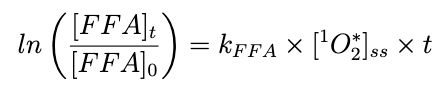

In [ ]:
#Don't worry, np.log is the natural logorithm, not base 10 (np.log10 is base 10)
Juglog=np.log([i/Jug[0] for i in Jug])
PNlog=np.log([i/PN[0] for i in PN])

# Obtain the slope using a 1st degree polynomial fit function 

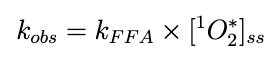

In [ ]:
#Obtain slope for all lines for quantum yield calculation, then take the negative to get kobs
#the [0] indicates I am pulling out the slope, i.e "m" in y=mx+b
kobsJug=-(np.polyfit(Jugtime,Juglog,1)[0])
kobsPN=-(np.polyfit(PNtime,PNlog,1)[0])

# Plot HPLC Results

In [ ]:
#Plot the results
plt.plot(PNtime,PNlog,'yo',label='Perinaphthenone')
plt.plot(PNtime,PNtime*(-kobsPN),'y--')

plt.plot(Jugtime,Juglog,'go',label='Juglone')
plt.plot(Jugtime,Jugtime*(-kobsJug),'g--')

#Plot legend and axis labels
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1),
          ncol=3, fancybox=True, shadow=True)
plt.ylabel('ln(${[FFA]_t}$/${[FFA]_0}$)',fontsize=12)
plt.xlabel('Irradiation time (sec)',fontsize=12)
plt.show()

# Rate of light absorbance calculation
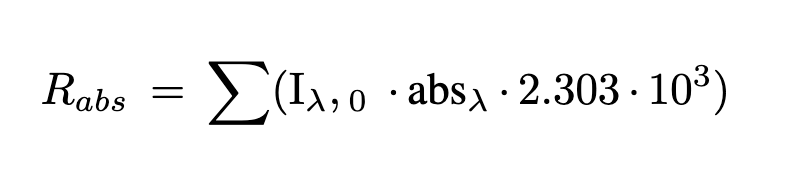

In [ ]:
R_abs_Jug=2.303*np.sum(Jug_abs.reset_index(drop=True)*I_abs_2NB.reset_index(drop=True))
print('R_abs Juglone =',R_abs_Jug,'mol_photons L⁻¹ s⁻¹')

R_abs_PN=2.303*np.sum(PN_abs.reset_index(drop=True)*I_abs_2NB.reset_index(drop=True))
print('R_abs Perinapthenone =',R_abs_PN,'mol_photons L⁻¹ s⁻¹')

# Calculate light screening factor
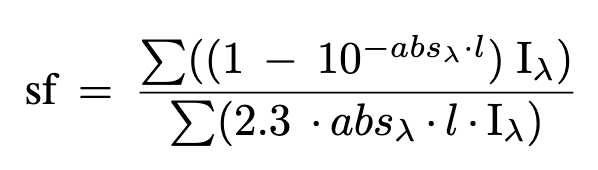

In [ ]:
sf_Jug=(np.sum((1-10**-Jug_abs.reset_index(drop=True))*I_abs_2NB.reset_index(drop=True)))/(np.sum((2.303*Jug_abs.reset_index(drop=True))*I_abs_2NB.reset_index(drop=True)))
print('Jug Screening Factor = ',sf_Jug)

sf_PN=(np.sum((1-10**-PN_abs.reset_index(drop=True))*I_abs_2NB.reset_index(drop=True)))/(np.sum((2.303*PN_abs.reset_index(drop=True))*I_abs_2NB.reset_index(drop=True)))
print('PN Screening Factor = ',sf_PN)


# Correct for light screening
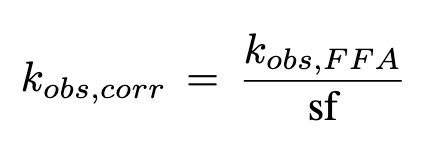

In [ ]:
kcorr_Jug=kobsJug/sf_Jug
kcorr_PN=kobsPN/sf_PN

# 1O2* Steady State Concentration 

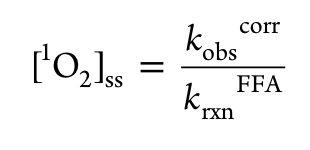

In [ ]:
Temp=___ #Put in your experimental temperature here, in degrees C
kffa=10**8 + (2.1E6*(Temp-22)) #from Appaini (2017)

SS_PN=kcorr_PN/kffa

print('Perinaphthenone Oxygen steady state concentration = ', SS_PN,'M') 

SS_Jug=kcorr_Jug/kffa
print('Juglone Oxygen steady state concentration = ', SS_Jug,'M') 

# Calculate Quantum yield
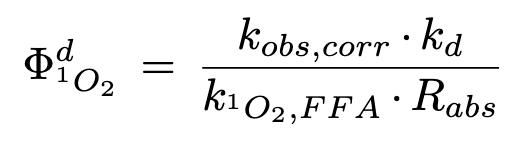

In [ ]:
kd=934.1813872772475*Temp + 258405.55551958136 #from Appaini (2017), data fitted using linear regression by me

quantum_PN=(kcorr_PN*kd)/(R_abs_PN*kffa)
print('Perinaphthenone Quantum yield=',quantum_PN*100,'%')

quantum_Jug=(kcorr_Jug*kd)/(R_abs_Jug*kffa)
print('Juglone Quantum yield=',quantum_Jug*100, '%')

# End of experimental Section 
---


# Guassian 16 Excited State Density Functional Theory Calculation Results
---

In [ ]:
#Constants
F=96.485 #kJ/V (Faraday constant) 
SHE=4.281 #V (absolute potential of the standard hydrogen electrode)
n=1 #for 1 electron transferred 
Hart_to_kJ=2625.49962 #Conversion of Hartree to kJ/mol
eV_to_kJ=96.485 #Conversion of eV to kJ/mol

# First Excited Triplet state energy

In [ ]:
#Put in values from output files where there is ___
T1_PN= ___ *eV_to_kJ #eV 
T1_Jug= ___ *eV_to_kJ #eV 

# Redox Potential

### Ground state redox potential calculation
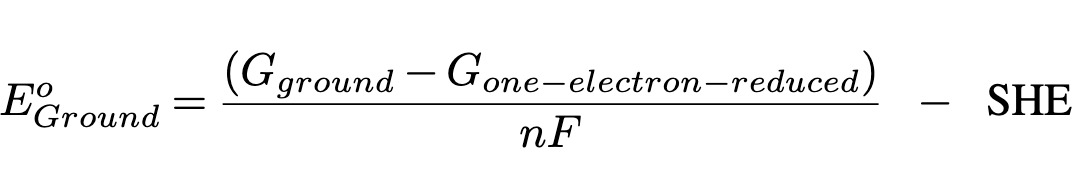

In [ ]:
# For PN
G_ground_PN= ___ #Hartree
G_one_e_reduced_PN= ___ #Hartree

E0_Ground_PN=(((Hart_to_kJ*(G_ground_PN-G_one_e_reduced_PN)))/(n*F))-SHE

########################################################################################################
# For Jug
G_ground_Jug= ___ #Hartree
G_one_e_reduced_Jug= ___ #Hartree

E0_Ground_Jug=(((Hart_to_kJ*(G_ground_Jug-G_one_e_reduced_Jug)))/(n*F))-SHE


### Excited state redox potential calculation
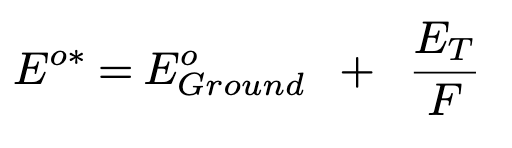

In [ ]:
E0_PN=E0_Ground_PN+((T1_PN)/F)
print('E_0 PN = ', E0_PN,'V')

E0_Jug=E0_Ground_Jug+((T1_Jug)/F)
print('E_0 Jug = ', E0_Jug,'V')

# Plot results

In [ ]:
# Data
Sens = ['PN', 'Jug']
E0s_arr = np.array([E0_PN,E0_Jug])
T1s_arr = np.array([T1_PN,T1_Jug])

plt.figure(figsize=(5, 4), dpi=300)

plt.axhline(y=94.3, color='red', linestyle='dashed')
plt.text(2, 105, '$^1$O$_2^*$($^1Δ_g$)(94.3 kJ/mol)', va='center', ha='right', color='red', fontsize=10)

plt.axvline(x=1.17, color='black', linestyle='dashed')
plt.text(1.27, 250, 'E$^0$ (SYR)(1.17 V)', va='center', ha='right', color='black', fontsize=10, rotation=90)

plt.axvline(x=2.18, color='black', linestyle='dashed')
plt.text(2.27, 160, 'E$^0$ (H$_2$O)(2.18 V)', va='center', ha='right', color='black', fontsize=10, rotation=90)


scatter = plt.scatter(E0s_arr, T1s_arr,s=100, edgecolor='black')

#*** Uncomment these lines once experimental data has been obtained ***
#QYs_arr = 100*np.array([quantum_PN,quantum_Jug]) #We use the quantum yields we calculated experimentally to visualize
#scatter = plt.scatter(E0s_arr, T1s_arr, c=QYs_arr,cmap='inferno', norm=LogNorm(vmin=0.08, vmax=100), s=100, edgecolor='black')
#cbar = plt.colorbar(scatter)
#cbar.set_label('ϕ$_{^1O_2^*}$ (%)',fontsize=13)



# Axis labels and title
plt.xlabel('Triplet state E⁰$^*$ (V, SHE)',fontsize=12)
plt.ylabel('Triplet Energy T₁ (kJ mol$^{-1}$)',fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Text annotations (editable positions)
plt.text(E0s_arr[0], T1s_arr[0]-20, 'PN')
plt.text(E0s_arr[1] + 0.05, T1s_arr[1]-0.03, 'Jug')

plt.tight_layout()
plt.ylim(85,330)
plt.xlim(0.9,2.5)
#plt.savefig('ET_E0')
plt.show()
